# Task 4: FICO Score Bucketing and Credit Rating

## JPMorgan Chase Quantitative Research Virtual Experience

**Author:** Ruth Wanjiru 

### Objective

Develop an optimized credit rating system by grouping borrowers into FICO score buckets that maximize the likelihood of the observed default behavior. The resulting rating system can be used in machine learning models that require categorical inputs.


## Business Background

Many machine learning algorithms and credit risk systems require categorical variables rather than continuous numerical values. Since FICO scores range from approximately 300 to 850, converting them into meaningful credit rating categories improves model interpretability while preserving important information about default risk.

This notebook develops an optimized bucketing strategy using dynamic programming and a log-likelihood objective function. The resulting rating map assigns borrowers to credit risk categories where lower ratings represent stronger credit quality and higher ratings represent greater default risk.


## Project Objectives

* Explore the distribution of FICO scores.
* Prepare cumulative borrower and default statistics.
* Implement a log-likelihood objective function.
* Apply dynamic programming to determine optimal FICO score buckets.
* Generate an optimized credit rating map.
* Create a reusable function that assigns ratings to future borrowers based on their FICO scores.


#### Import Libraries

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### Load the Dataset

In [3]:
# Load dataset
df = pd.read_csv("Task 3 and 4_Loan_Data.csv")

In [4]:
df.head()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   credit_lines_outstanding  10000 non-null  int64  
 2   loan_amt_outstanding      10000 non-null  float64
 3   total_debt_outstanding    10000 non-null  float64
 4   income                    10000 non-null  float64
 5   years_employed            10000 non-null  int64  
 6   fico_score                10000 non-null  int64  
 7   default                   10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB


In [6]:
df.isnull().sum()

customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64

#### Explore the FICO Scores

In [7]:
# Create the working dataset
fico_data = df[["fico_score", "default"]].copy()
fico_data = fico_data.sort_values("fico_score").reset_index(drop=True)

fico_data.head()

,fico_score,default
0,408,0
1,409,1
2,418,1
3,425,1
4,438,1


In [8]:
# Explore the FICO scores
fico_data["fico_score"].describe()

count    10000.000000
mean       637.557700
std         60.657906
min        408.000000
25%        597.000000
50%        638.000000
75%        679.000000
max        850.000000
Name: fico_score, dtype: float64

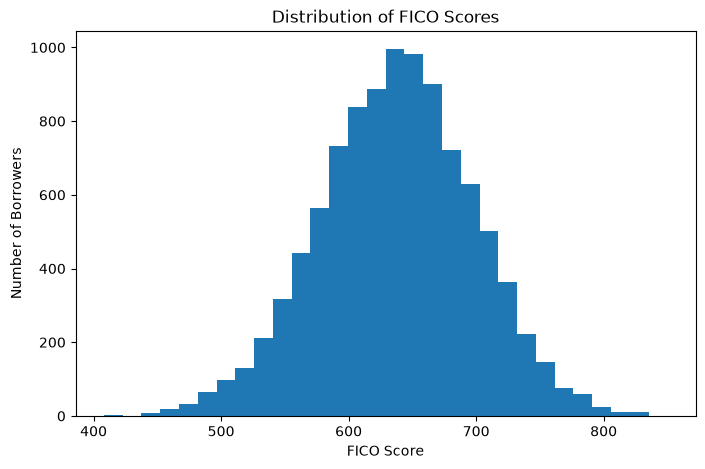

In [9]:
# Plot the FICO scores distribution
plt.figure(figsize=(8,5))
plt.hist(fico_data["fico_score"], bins=30)

plt.title("Distribution of FICO Scores")
plt.xlabel("FICO Score")
plt.ylabel("Number of Borrowers")

plt.show()

#### Prepare the Data for Optimization

In [11]:
# How defaults vary with FICO scores
fico_data["fico_group"] = pd.cut(fico_data["fico_score"], bins=10)

fico_data.groupby("fico_score")["default"].mean().head(10)

fico_score
408    0.0
409    1.0
418    1.0
425    1.0
438    1.0
440    1.0
441    1.0
444    0.0
447    0.0
449    1.0
Name: default, dtype: float64

In [12]:
fico_data.groupby("fico_score")["default"].mean().tail(10)

fico_score
816    0.0
822    0.0
823    0.0
824    0.0
825    0.0
826    0.0
828    0.0
831    0.0
835    0.0
850    0.0
Name: default, dtype: float64

In [13]:
# Keep only the required columns
fico_data = df[["fico_score", "default"]].copy()

# Sort by FICO score
fico_data = fico_data.sort_values("fico_score").reset_index(drop=True)

# Count borrowers and defaults for each FICO score
fico_summary = (fico_data.groupby("fico_score").agg(total_borrowers=("default", "count"), defaults=("default", "sum")
                                                   )
               .reset_index()
               )

fico_summary.head()

,fico_score,total_borrowers,defaults
0,408,1,0
1,409,1,1
2,418,1,1
3,425,1,1
4,438,1,1


In [14]:
fico_summary.shape

(374, 3)

In [15]:
# Cumulative number of borrowers
fico_summary["cum_total"] = fico_summary["total_borrowers"].cumsum()

# Cumulative number of defaults
fico_summary["cum_defaults"] = fico_summary["defaults"].cumsum()

fico_summary.head()

,fico_score,total_borrowers,defaults,cum_total,cum_defaults
0,408,1,0,1,0
1,409,1,1,2,1
2,418,1,1,3,2
3,425,1,1,4,3
4,438,1,1,5,4


In [16]:
# Define the bucket log-likelihood function
def bucket_log_likelihood(total_borrowers, defaults):
    """
    Calculate the log-likelihood for a single bucket.
    """

    # Avoid log(0)
    if defaults == 0 or defaults == total_borrowers:
        return 0

    pd = defaults / total_borrowers

    log_likelihood = (
        defaults * np.log(pd)
        + (total_borrowers - defaults) * np.log(1 - pd)
    )

    return log_likelihood 

In [17]:
print(bucket_log_likelihood(100, 10))
print(bucket_log_likelihood(100, 50))
print(bucket_log_likelihood(100, 90))

-32.50829733914482
-69.31471805599453
-32.508297339144825


In [18]:
# Calculate log-likelihood for any range of rows
def evaluate_bucket(start, end):
    """
    Calculate the log-likelihood for a bucket
    covering rows start through end (inclusive).
    """

    if start == 0:
        total = fico_summary.loc[end, "cum_total"]
        defaults = fico_summary.loc[end, "cum_defaults"]
    else:
        total = (
            fico_summary.loc[end, "cum_total"]
            - fico_summary.loc[start - 1, "cum_total"]
        )

        defaults = (
            fico_summary.loc[end, "cum_defaults"]
            - fico_summary.loc[start - 1, "cum_defaults"]
        )

    return bucket_log_likelihood(total, defaults)

In [19]:
print(evaluate_bucket(0, 20))
print(evaluate_bucket(21, 60))
print(evaluate_bucket(61, 120))

-19.012160727194832
-102.03127280768271
-711.9467194044621


In [20]:
# Dynamic programming algorithm
num_buckets = 5

n = len(fico_summary)

dp = np.full((n + 1, num_buckets + 1), -np.inf)
split = np.zeros((n + 1, num_buckets + 1), dtype=int)

dp[0][0] = 0

for k in range(1, num_buckets + 1):

    for i in range(k, n + 1):

        best_score = -np.inf
        best_split = 0

        for j in range(k - 1, i):

            score = dp[j][k - 1] + evaluate_bucket(j, i - 1)

            if score > best_score:
                best_score = score
                best_split = j

        dp[i][k] = best_score
        split[i][k] = best_split

In [21]:
dp[n][num_buckets]

np.float64(-4255.377391458947)

#### Recover Optimal Bucket Boundaries

In [22]:
# Recover the bucket boundaries (backtracking)
boundaries = []

i = n
k = num_buckets

while k > 0:
    j = split[i][k]
    boundaries.append((j, i - 1))
    i = j
    k -= 1

boundaries.reverse()

boundaries

[(np.int64(0), np.int64(73)),
 (np.int64(74), np.int64(133)),
 (np.int64(134), np.int64(193)),
 (np.int64(194), np.int64(249)),
 (np.int64(250), 373)]

#### Create the Credit Rating Map

In [24]:
# Convert row numbers in FICO score ranges
rating_map = []

for idx, (start, end) in enumerate(boundaries):

    rating = len(boundaries) - idx

    min_score = fico_summary.loc[start, "fico_score"]
    max_score = fico_summary.loc[end, "fico_score"]

    total = (
        fico_summary.loc[end, "cum_total"]
        if start == 0
        else fico_summary.loc[end, "cum_total"]
             - fico_summary.loc[start - 1, "cum_total"]
    )

    defaults = (
        fico_summary.loc[end, "cum_defaults"]
        if start == 0
        else fico_summary.loc[end, "cum_defaults"]
             - fico_summary.loc[start - 1, "cum_defaults"]
    )

    pd_rate = defaults / total

    rating_map.append({
        "Rating": rating,
        "Min FICO": min_score,
        "Max FICO": max_score,
        "Borrowers": total,
        "Defaults": defaults,
        "PD": round(pd_rate, 4)
    })

rating_df = pd.DataFrame(rating_map)

rating_df

,Rating,Min FICO,Max FICO,Borrowers,Defaults,PD
0,5,408,520,301,199,0.6611
1,4,521,580,1407,536,0.3810
2,3,581,640,3438,703,0.2045
3,2,641,696,3197,336,0.1051
4,1,697,850,1657,77,0.0465


#### Rating Assignment Function

In [29]:
# Create a reusable rating function
def assign_rating(fico_score):
    """
    Assign a credit rating based on the optimized FICO score buckets.
    """

    for _, row in rating_df.iterrows():

        if row["Min FICO"] <= fico_score <= row["Max FICO"]:
            return int(row["Rating"])

    return None

In [30]:
rating_df

,Rating,Min FICO,Max FICO,Borrowers,Defaults,PD
0,5,408,520,301,199,0.6611
1,4,521,580,1407,536,0.3810
2,3,581,640,3438,703,0.2045
3,2,641,696,3197,336,0.1051
4,1,697,850,1657,77,0.0465


#### Results

In [31]:
print(rating_df[["Rating", "Min FICO", "Max FICO"]])

   Rating  Min FICO  Max FICO
0       5       408       520
1       4       521       580
2       3       581       640
3       2       641       696
4       1       697       850


In [32]:
print(assign_rating(750))
print(assign_rating(680))
print(assign_rating(620))
print(assign_rating(550))
print(assign_rating(450))

1
2
3
4
5


# Conclusion

This notebook developed an optimized credit rating system by partitioning continuous FICO scores into discrete risk categories using a dynamic programming approach that maximizes the log-likelihood of observed default behavior.

The resulting rating map successfully grouped borrowers into five credit quality categories, with higher FICO scores corresponding to lower probabilities of default and lower FICO scores corresponding to higher default risk. This optimized categorization preserves meaningful credit risk information while producing categorical inputs suitable for downstream machine learning applications and credit risk models.

The completed rating system provides a scalable and reusable framework for assigning future borrowers to appropriate credit risk categories based on their FICO scores.
